# Classical vs learned vs end-to-end echo cancellation — measured

MuTap's echo canceller is classical DSP: a linear frequency-domain Kalman
canceller plus a coherence-driven residual suppressor
([`postfilter.h`](../include/mutap/postfilter.h)). This notebook puts that
chain side by side with two machine-learning alternatives **on identical
signals, through one meter**:

- **`mutap-kalman+nn`** — the *hybrid* from [`tools/ml`](../tools/ml):
  the same linear canceller, with the residual post-filter replaced by a
  51k-parameter GRU predicting per-band gains
  ([`nn_suppressor.h`](../include/mutap/nn_suppressor.h), trained on
  clean-licensed LibriSpeech mixtures by this repo's own pipeline).
- **DTLN-aec** — a published *end-to-end* neural AEC (Westhausen & Meyer,
  ICASSP 2021, MIT), 10.4M parameters, as the "replace everything with a
  network" reference point.

The scenario is the test rig's double-talk protocol
([`test_aec.cpp`](../tests/test_aec.cpp)) plus a near-end-only segment:
**converge** (far end only) → **double-talk** (near end at 0 dB) →
**recovery** (far only) → **near-only** (the canceller should pass this
untouched). Licensing context and the full result tables:
[`tools/ml/README.md`](../tools/ml/README.md).

Sections needing external downloads (LibriSpeech speech, DTLN models)
skip visibly if those are absent; every committed figure was produced by
a full run.

In [1]:
import os, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / "tools" / "ml"))
import features, metrics, mutap_ffi, nn

BUILD = REPO / "build-ml"
def _run(cmd):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed")

if not (BUILD / "tools/ml/aec_scenario_dump").exists():
    _run(["cmake", "-S", REPO, "-B", BUILD, "-DCMAKE_BUILD_TYPE=Release",
          "-DMUTAP_BUILD_CAPI=ON", "-DMUTAP_BUILD_ML_TOOLS=ON", "-DMUTAP_BUILD_TESTS=OFF"])
    _run(["cmake", "--build", BUILD, "--target", "mutap_capi", "aec_scenario_dump", "-j"])
lib = mutap_ffi.load_library(BUILD)

WEIGHTS = REPO / "tools/ml/pretrained/suppressor_v1.munn"
DTLN_DIR = os.environ.get("MUTAP_DTLN_DIR", "/workspace/breizhn/dtln-aec/pretrained_models")
HAVE_DTLN = pathlib.Path(DTLN_DIR, "dtln_aec_512_1.tflite").exists()
LIBRI = os.environ.get("MUTAP_LIBRISPEECH",
                       "/tmp/claude-0/-home-user/425f09f3-c52d-5603-aaf0-eebeab94b576/scratchpad/speech/LibriSpeech/dev-clean-2")
HAVE_SPEECH = pathlib.Path(LIBRI).exists()
print(f"DTLN models: {'found' if HAVE_DTLN else 'ABSENT (sections skipped)'};",
      f"speech corpus: {'found' if HAVE_SPEECH else 'ABSENT (sections skipped)'}")

DTLN models: found; speech corpus: found


## The systems

All four share one call shape — far-end reference and microphone in,
cleaned signal out — so the comparison swaps nothing but the algorithm.
The meter delay-compensates each system (`metrics.find_delay`), so
differing internal latencies don't skew any number.

In [2]:
BLOCK, PARTS = 64, 16

def sys_linear():  return mutap_ffi.KalmanCanceller(lib, BLOCK, PARTS)
def sys_chain():   return mutap_ffi.AecChain(lib, BLOCK, PARTS, 16000.0)
def sys_hybrid():  return nn.KalmanNnSystem(lib, BLOCK, PARTS, str(WEIGHTS))
SYSTEMS = [("kalman linear", sys_linear), ("chain (classical post)", sys_chain),
           ("kalman + GRU (hybrid)", sys_hybrid)]
if HAVE_DTLN:
    import dtln_aec
    SYSTEMS.append(("DTLN-aec 512 (end-to-end)",
                    lambda: dtln_aec.DtlnAec(str(pathlib.Path(DTLN_DIR) / "dtln_aec_512"))))

def run_all(scn):
    out = {}
    for name, make in SYSTEMS:
        e = make().process(scn.x, scn.y)
        d = metrics.find_delay(scn, e)
        out[name] = (np.concatenate((e[d:], np.zeros(d))), metrics.measure(scn, e))
    return out

def residual_trace_db(scn, e, smooth_blocks=25):
    r = e - scn.v                      # what is neither near end nor silence
    p = np.sum(r[: len(r) - len(r) % scn.block].reshape(-1, scn.block) ** 2, axis=1)
    k = np.ones(smooth_blocks) / smooth_blocks
    return 10 * np.log10(np.convolve(p, k, mode="same") / scn.block + 1e-12)

def plot_scenario(scn, results, title):
    fig, ax = plt.subplots(figsize=(11, 4.2))
    edges = [b[0] // scn.block for b in scn.bounds.values()] + [len(scn.x) // scn.block]
    for name, (e, _) in results.items():
        ax.plot(residual_trace_db(scn, e), label=name, lw=1.1)
    ax.plot(residual_trace_db(scn, scn.y), color="0.75", lw=0.8, zorder=0,
            label="no canceller (mic)")
    for x0 in edges[1:-1]:
        ax.axvline(x0, color="k", lw=0.6, alpha=0.4)
    for (segname, (lo, hi)) in scn.bounds.items():
        ax.text((lo + hi) / 2 / scn.block, ax.get_ylim()[1], segname,
                ha="center", va="bottom", fontsize=8, alpha=0.7)
    ax.set(xlabel="block", ylabel="residual level (dB)", title=title)
    ax.legend(loc="lower left", fontsize=8)
    fig.tight_layout()
    return fig

## Scenario 1 — the rig's own material (synthetic, out of any
network's training domain)

Speech-envelope AR far end, music near end (the material the
frequency-warped predictor exists for), studio room, seed 2 — the exact
protocol `test_aec.cpp` gates. The **residual trace** below is
everything in each output that is *not* the near end: residual echo
during the talk segments, and *near-end damage* in the final
`near_only` segment, where a perfect system would sit at −∞.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


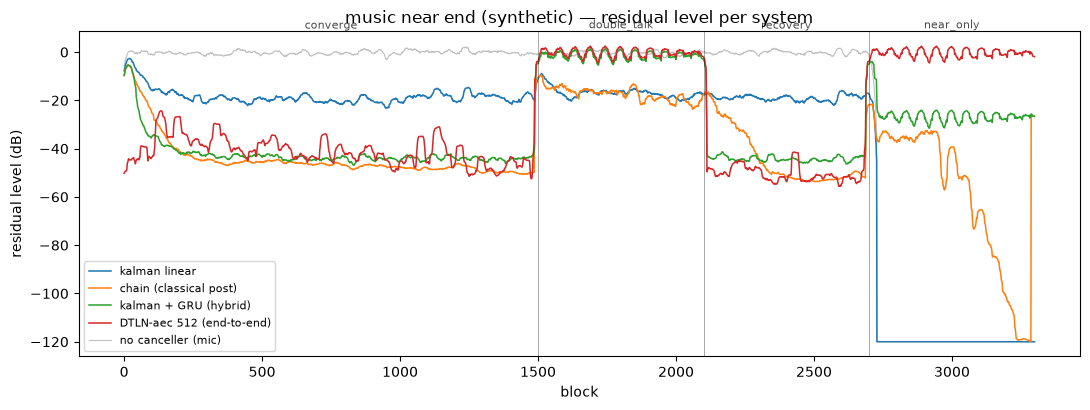

In [3]:
SCEN = REPO / "build-ml" / "nb-scenarios"
def dump(material, seed, room="studio"):
    folder = SCEN / f"{material}-s{seed}-{room}"
    if not (folder / "manifest.json").exists():
        folder.mkdir(parents=True, exist_ok=True)
        _run([BUILD / "tools/ml/aec_scenario_dump", folder, material, seed, room])
    return metrics.Scenario.load(folder)

scn_music = dump("music", 2)
res_music = run_all(scn_music)
plot_scenario(scn_music, res_music, "music near end (synthetic) — residual level per system");

Read the `double_talk` and `near_only` segments. The classical
systems' residual stays well below the mic line and **`near_only` drops
toward the floor** — they pass unfamiliar material untouched. The hybrid
tracks the classical chain through `converge`/`recovery` (its learned
gains suppress residual echo hard) but its double-talk advantage is
gone on this material: the GRU never saw music as a near end. DTLN-aec
(when present) is the extreme case: its `near_only` residual sits AT the
near-end level — the network is *deleting the talker*. Numbers:

In [4]:
def table(results):
    hdr = f"{'system':>26} | {'stERLE':>7} | {'dtSUP':>6} | {'recERLE':>7} | {'neSDR':>6} | delay"
    print(hdr); print("-" * len(hdr))
    for name, (_, m) in results.items():
        print(f"{name:>26} | {m.st_erle_db:7.1f} | {m.dt_suppression_db:6.1f} | "
              f"{m.rec_erle_db:7.1f} | {m.ne_sdr_db:6.1f} | {m.delay_samples}")
table(res_music)

                    system |  stERLE |  dtSUP | recERLE |  neSDR | delay
------------------------------------------------------------------------
             kalman linear |    18.0 |   15.7 |    19.0 |   80.0 | 0
    chain (classical post) |    41.8 |   15.9 |    47.5 |   36.1 | 64
     kalman + GRU (hybrid) |    43.4 |    0.8 |    43.9 |   26.5 | 0
 DTLN-aec 512 (end-to-end) |    38.7 |   -0.3 |    42.8 |    0.0 | 747


## Scenario 2 — real speech (every system's best case)

LibriSpeech far end and near end, a random room with bulk delay — the
material DTLN-aec was trained for, and the material MuTap's own GRU was
trained on (from *different*, clean-licensed recordings and different
speakers).

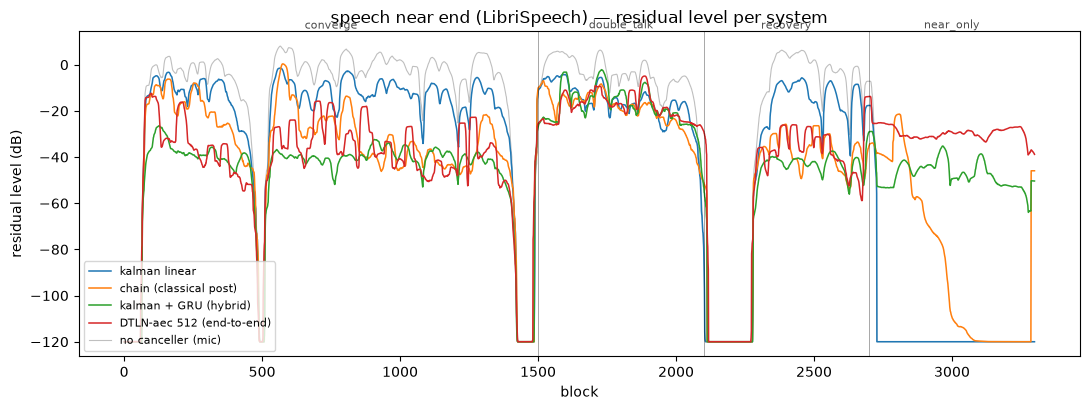

In [5]:
if HAVE_SPEECH:
    scen_dir = SCEN / "speech"
    if not any(scen_dir.glob("*/manifest.json")):
        _run([sys.executable, REPO / "tools/ml/make_dataset.py", "--corpus", LIBRI,
              "--scenarios", scen_dir, "--examples", "1", "--seed", "7",
              "--build-dir", BUILD])
    folder = sorted(scen_dir.glob("*/manifest.json"))[0].parent
    scn_speech = metrics.Scenario.load(folder)
    res_speech = run_all(scn_speech)
    plot_scenario(scn_speech, res_speech, "speech near end (LibriSpeech) — residual level per system")
else:
    print("speech corpus absent — set MUTAP_LIBRISPEECH to a LibriSpeech split (openslr.org/31)")

In [6]:
if HAVE_SPEECH:
    table(res_speech)

                    system |  stERLE |  dtSUP | recERLE |  neSDR | delay
------------------------------------------------------------------------
             kalman linear |    12.0 |   10.9 |    12.3 |   80.0 | 0
    chain (classical post) |    30.9 |   15.0 |    34.0 |   34.9 | 64
     kalman + GRU (hybrid) |    40.3 |   11.3 |    43.2 |   44.6 | 0
 DTLN-aec 512 (end-to-end) |    31.5 |   14.2 |    26.3 |   29.3 | 384


In domain, every learner earns its keep: the hybrid's residual
drops *below* the classical chain through the single-talk segments
(that is the learned suppressor beating the coherence rule at its own
game, with the same linear canceller underneath), and DTLN posts strong
echo removal. The ordering that matters is in `double_talk` and
`near_only`: the classical chain and the hybrid keep the near end
essentially intact (≈38 dB SDR), DTLN colors it audibly (≈29 dB).

## What the learned gains are actually doing

The hybrid's whole action is 22 band gains per 4 ms block on the
canceller's output. Watching them across the protocol is the clearest
picture of learned behavior — and of the domain question.

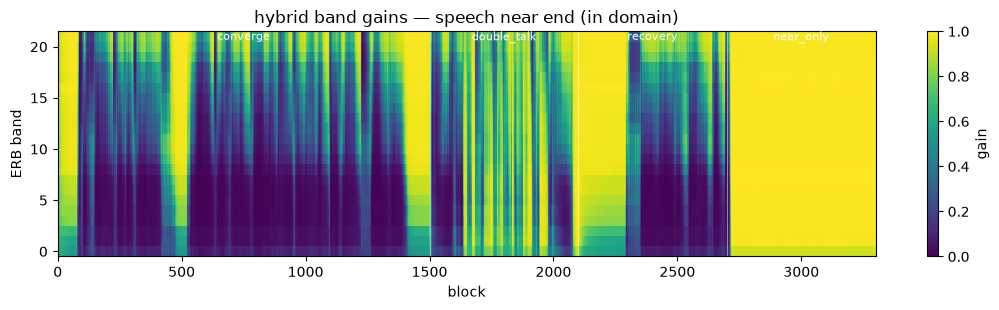

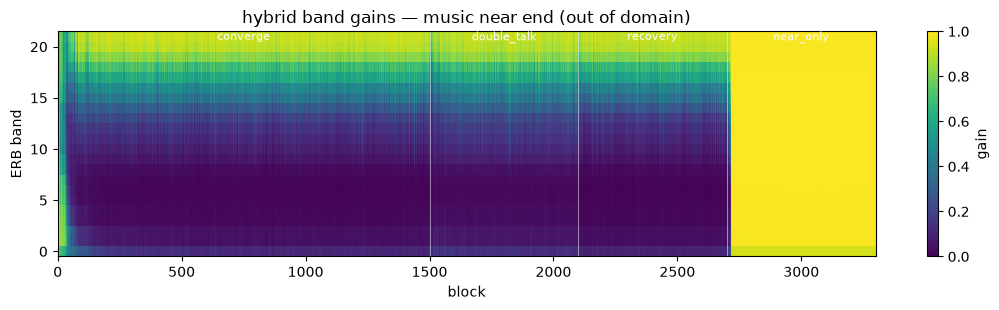

In [7]:
def gain_heatmap(scn, title):
    c = mutap_ffi.KalmanCanceller(lib, BLOCK, PARTS)
    e = c.process(scn.x, scn.y)
    net = nn.SuppressorNet(str(WEIGHTS))
    g = net.process(features.features_from(e, scn.y - e).astype(np.float64))
    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(g.T, aspect="auto", origin="lower", vmin=0, vmax=1,
                   cmap="viridis", interpolation="nearest")
    for (segname, (lo, hi)) in scn.bounds.items():
        ax.axvline(lo // scn.block, color="w", lw=0.6, alpha=0.6)
        ax.text((lo + hi) / 2 / scn.block, 21.5, segname, ha="center",
                va="top", fontsize=8, color="w")
    ax.set(xlabel="block", ylabel="ERB band", title=title)
    fig.colorbar(im, label="gain")
    fig.tight_layout()

if HAVE_SPEECH:
    gain_heatmap(scn_speech, "hybrid band gains — speech near end (in domain)")
gain_heatmap(scn_music, "hybrid band gains — music near end (out of domain)")

On speech the gains do exactly what the classical Wiener rule
aspires to: clamped low while only residual echo is present, snapping
open band-by-band wherever (and only where) the talker has energy, shut
again in the pauses — a coherence gate learned from data. On music the
failure is legible: the sustained chord's bands flicker instead of
holding open, which is precisely the double-talk suppression the metric
shows evaporating — and since the gains only ever act on the linear
canceller's output within [0, 1], the damage is bounded coloration, not
DTLN-style deletion.

## Takeaways

1. **Keep the classical chain as the default engine.** It is the only
   system whose double-talk suppression and transparency hold for
   arbitrary program material — the property MuTap promises.
2. **The hybrid is real**: +5 dB single-talk ERLE over the classical
   post-filter on speech at equal transparency, 51k parameters,
   embedded-feasible, and every training input clean-licensed. Its
   off-domain weakness is a *data* problem this repo's generator can
   attack directly (train on the rig's own materials); DTLN's weakness
   is structural.
3. **End-to-end stays a benchmark, not a candidate** — for the measured
   near-end deletion, the certification opacity, and the training-data
   licensing alone.